# 第五章实验 1：可视化特征与图像分类

本实验完全离线运行。程序自动生成带有随机位置、尺度、旋转、颜色和轻微噪声的
**圆形、正方形、三角形**图像，然后：

1. 可视化颜色直方图和形状边界；
2. 提取面积比、圆形度、外接矩形填充率和径向变化四个特征；
3. 使用最近质心分类器完成三分类；
4. 显示混淆矩阵和测试图像预测结果。


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SEED = 2026
rng = np.random.default_rng(SEED)
CLASS_NAMES = np.array(["circle", "square", "triangle"])
CLASS_COLORS = np.array([
    [0.90, 0.20, 0.20],
    [0.15, 0.65, 0.25],
    [0.15, 0.35, 0.90],
])

def polygon_mask(height, width, vertices):
    '''Vectorized ray-casting test: pixels inside an arbitrary polygon.'''
    yy, xx = np.mgrid[:height, :width]
    x = xx + 0.5
    y = yy + 0.5
    inside = np.zeros((height, width), dtype=bool)
    vertices = np.asarray(vertices, dtype=float)
    j = len(vertices) - 1
    for i in range(len(vertices)):
        xi, yi = vertices[i]
        xj, yj = vertices[j]
        crosses = ((yi > y) != (yj > y))
        x_cross = (xj - xi) * (y - yi) / (yj - yi + 1e-12) + xi
        inside ^= crosses & (x < x_cross)
        j = i
    return inside

def shape_mask(kind, size=64, center=None, scale=0.52, angle=0.0):
    '''Create a circle, square or triangle mask.'''
    cy, cx = center if center is not None else (size / 2, size / 2)
    yy, xx = np.mgrid[:size, :size]
    radius = size * scale / 2
    if kind == 0:
        return (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2

    count = 4 if kind == 1 else 3
    base = angle + (-np.pi / 4 if kind == 1 else -np.pi / 2)
    angles = base + np.arange(count) * 2 * np.pi / count
    vertices = np.column_stack([
        cx + radius * np.cos(angles),
        cy + radius * np.sin(angles),
    ])
    return polygon_mask(size, size, vertices)

def render_shape(kind, size=64, center=None, scale=0.52, angle=0.0,
                 color=None, noise=0.015, rng=rng):
    mask = shape_mask(kind, size, center, scale, angle)
    image = np.full((size, size, 3), 0.96, dtype=float)
    if color is None:
        color = CLASS_COLORS[kind]
    image[mask] = color
    image += rng.normal(0, noise, image.shape)
    return np.clip(image, 0, 1), mask

def foreground_mask(image):
    '''Separate colorful/dark objects from the nearly white background.'''
    return np.linalg.norm(image - 0.96, axis=2) > 0.20

def binary_perimeter(mask):
    padded = np.pad(mask, 1, constant_values=False)
    eroded = (
        padded[1:-1, 1:-1]
        & padded[:-2, 1:-1]
        & padded[2:, 1:-1]
        & padded[1:-1, :-2]
        & padded[1:-1, 2:]
    )
    return mask & ~eroded

def extract_features(image):
    '''Area ratio, circularity, extent and radial-distance variation.'''
    mask = foreground_mask(image)
    ys, xs = np.where(mask)
    area = float(mask.sum())
    perimeter = float(binary_perimeter(mask).sum())
    height = ys.max() - ys.min() + 1
    width = xs.max() - xs.min() + 1
    extent = area / (height * width)
    circularity = 4 * np.pi * area / max(perimeter ** 2, 1)
    cy, cx = ys.mean(), xs.mean()
    by, bx = np.where(binary_perimeter(mask))
    radii = np.sqrt((by - cy) ** 2 + (bx - cx) ** 2)
    radial_cv = radii.std() / max(radii.mean(), 1e-6)
    area_ratio = area / mask.size
    return np.array([area_ratio, circularity, extent, radial_cv])

def make_classification_dataset(
    samples_per_class=80, scale_range=(0.43, 0.62), rng=rng
):
    images, labels, features = [], [], []
    for label in range(3):
        for _ in range(samples_per_class):
            scale = rng.uniform(*scale_range)
            offset = rng.integers(-5, 6, size=2)
            angle = rng.uniform(-0.25, 0.25)
            color = rng.uniform(0.12, 0.88, size=3)
            if color.mean() > 0.72:
                color *= 0.65
            image, _ = render_shape(
                label,
                center=(32 + offset[0], 32 + offset[1]),
                scale=scale,
                angle=angle,
                color=color,
                rng=rng,
            )
            images.append(image)
            labels.append(label)
            features.append(extract_features(image))
    return np.asarray(images), np.asarray(labels), np.asarray(features)

class NearestCentroidClassifier:
    '''A tiny, interpretable classifier with one prototype per class.'''
    def fit(self, X, y):
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0) + 1e-8
        Z = (X - self.mean_) / self.scale_
        self.classes_ = np.unique(y)
        self.centroids_ = np.vstack([Z[y == c].mean(axis=0) for c in self.classes_])
        return self

    def predict(self, X):
        Z = (X - self.mean_) / self.scale_
        distances = ((Z[:, None, :] - self.centroids_[None, :, :]) ** 2).sum(axis=2)
        return self.classes_[distances.argmin(axis=1)]

## 1. 颜色与形状特征可视化

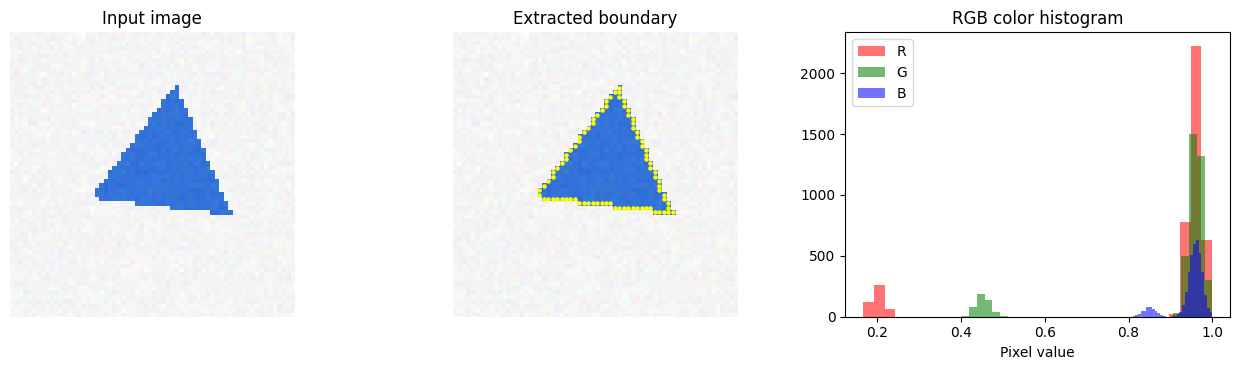

{'面积比': 0.108, '圆形度': 0.83, '填充率': 0.494, '径向变化': 0.224}


In [3]:
demo, demo_mask = render_shape(
    kind=2, center=(30, 35), scale=0.58, angle=0.12,
    color=np.array([0.20, 0.45, 0.85])
)
edge = binary_perimeter(demo_mask)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].imshow(demo)
axes[0].set_title("Input image")
axes[1].imshow(demo)
ey, ex = np.where(edge)
axes[1].scatter(ex, ey, s=5, c="yellow")
axes[1].set_title("Extracted boundary")
for channel, color, name in zip(range(3), "rgb", ["R", "G", "B"]):
    axes[2].hist(demo[..., channel].ravel(), bins=32, alpha=0.55,
                 color=color, label=name)
axes[2].set_title("RGB color histogram")
axes[2].set_xlabel("Pixel value")
axes[2].legend()
axes[0].axis("off")
axes[1].axis("off")
plt.tight_layout()
plt.show()

names = ["面积比", "圆形度", "填充率", "径向变化"]
print(dict(zip(names, np.round(extract_features(demo), 3))))

## 2. 自动生成数据集

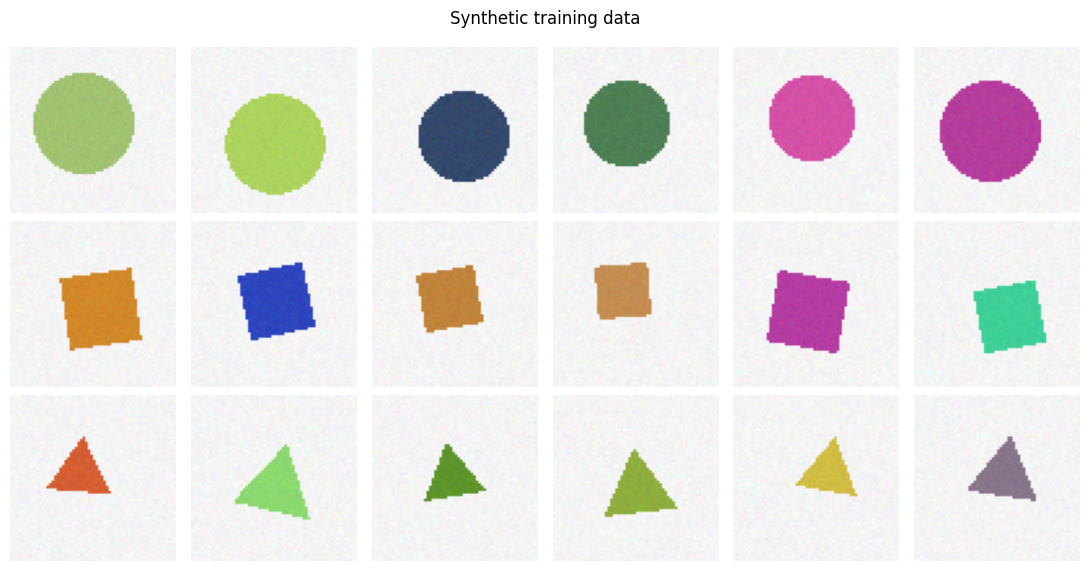

数据形状: (240, 64, 64, 3)
每类样本数: [80 80 80]


In [4]:
images, labels, features = make_classification_dataset(samples_per_class=80)

fig, axes = plt.subplots(3, 6, figsize=(11, 5.8))
for row, label in enumerate(range(3)):
    indices = np.where(labels == label)[0][:6]
    for ax, idx in zip(axes[row], indices):
        ax.imshow(images[idx])
        ax.axis("off")
    axes[row, 0].set_ylabel(CLASS_NAMES[label], fontsize=12)
plt.suptitle("Synthetic training data")
plt.tight_layout()
plt.show()

print("数据形状:", images.shape)
print("每类样本数:", np.bincount(labels))

## 3. 训练简单模型并评价

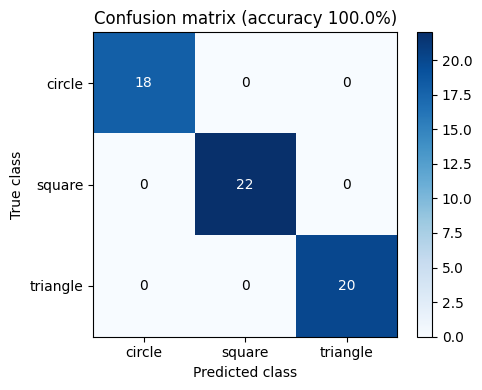

测试集准确率: 100.00%


In [5]:
order = rng.permutation(len(labels))
split = int(len(order) * 0.75)
train_idx, test_idx = order[:split], order[split:]

model = NearestCentroidClassifier().fit(features[train_idx], labels[train_idx])
pred = model.predict(features[test_idx])
accuracy = (pred == labels[test_idx]).mean()

confusion = np.zeros((3, 3), dtype=int)
for truth, guess in zip(labels[test_idx], pred):
    confusion[truth, guess] += 1

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, confusion[i, j], ha="center", va="center",
                color="white" if confusion[i, j] > confusion.max() / 2 else "black")
ax.set_xticks(range(3), CLASS_NAMES)
ax.set_yticks(range(3), CLASS_NAMES)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title(f"Confusion matrix (accuracy {accuracy:.1%})")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print(f"测试集准确率: {accuracy:.2%}")

## 4. 可视化预测结果

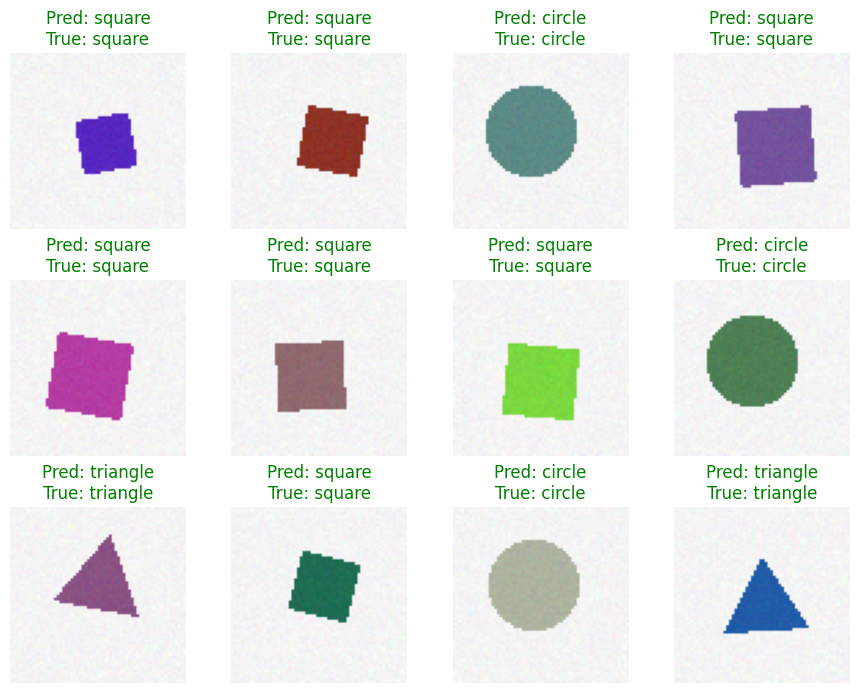

In [6]:
show_idx = test_idx[:12]
show_pred = model.predict(features[show_idx])
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for ax, idx, guess in zip(axes.ravel(), show_idx, show_pred):
    truth = labels[idx]
    ax.imshow(images[idx])
    ax.set_title(
        f"Pred: {CLASS_NAMES[guess]}\nTrue: {CLASS_NAMES[truth]}",
        color="green" if guess == truth else "red",
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

## 结论

这个小实验刻意使用简单模型：当类别可由清晰的形状特征区分时，最近质心分类器
已经足够有效。它也揭示了传统识别流程：

**图像 → 分割前景 → 提取特征 → 分类器 → 类别。**